In [15]:
import pandas as pd
import os
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import math
import matplotlib.cm as cm
import random
import scipy.signal as sp
import seaborn as sns
from IPython.display import display
from scipy.stats import kruskal

#### Read

In [16]:
def Load_All_ECG(base_path=r"F:\data\Code\final\ecg 60s 10min\features"):
    import os, pandas as pd

    ecg_data = {}

    for file in os.listdir(base_path):
        if file.startswith("ECG") :
            key = file.replace(".csv", "")   
            ecg_data[key] = pd.read_csv(os.path.join(base_path, file))

    return ecg_data

In [17]:
def convert(df, label_col='label'):

    df = df.copy()
    df.loc[df[label_col] == 'postictal', label_col] = 'normal'
    return df

In [18]:
def Run_ECG_Function(ecg_dict, ecg_name, func_name, label_col='label'):

    df = ecg_dict[ecg_name]
 
    if func_name == "box":
        Plot_Boxplots(df, label_col)

    elif func_name == "violin":
        Plot_Violin(df, label_col)

    elif func_name == "dist":
        Plot_Distribution(df, label_col)

    elif func_name == "hist":
        Plot_Histograms(df, label_col)

    elif func_name == "corr":
        Plot_Correlation(df)

    elif func_name == "analysis":
        Analysis_Feature(df, label_col)

    elif func_name == "stats":
        result = Full_Analysis(df, label_col)
        return result

    else:
        raise ValueError("Function must be one of: box, violin, dist, hist, corr, analysis, stats")

#### Ranges

In [19]:
def Analysis_Feature(df, label_col='label', exclude_cols=None):
    import pandas as pd

    if label_col not in df.columns:
        raise ValueError(f"'{label_col}' not found in DataFrame")

    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    exclude = ['subject', 'run', 'sfreq', 'start_time', 'end_time']
    if exclude_cols:
        exclude.extend(exclude_cols)

    features = [col for col in numeric_cols if col not in exclude]
    print(f"Analyzing {len(features)} numeric features: {features}\n")

    for feature in features:
        ranges_list = []

        for label in df[label_col].unique():
            values = df[df[label_col] == label][feature].dropna()
            if len(values) == 0:
                continue
            stats = {
                'Label': label,
                'Min': values.min(),
                'Max': values.max(),
                'Mean': values.mean(),
                'Std': values.std(),
                'Median': values.median(),
                '25th_percentile': values.quantile(0.25),
                '75th_percentile': values.quantile(0.75)
            }
            ranges_list.append(stats)

        df_feature = pd.DataFrame(ranges_list)

        df_feature = df_feature.sort_values(by='Mean', ascending=False).reset_index(drop=True)

        print(f"==== Feature: {feature} ====")
        display(df_feature)

In [20]:
def Full_Analysis(df, label_col='label', exclude_cols=None):

    if label_col not in df.columns:
        raise ValueError(f"'{label_col}' not found in DataFrame")

    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

    exclude = ['subject', 'run', 'encoded_label', 'sfreq',
               'start_time', 'end_time']

    if exclude_cols:
        exclude.extend(exclude_cols)

    features = [col for col in numeric_cols if col not in exclude]

    results = []

    for feature in features:
        groups = [
            df[df[label_col] == lbl][feature].dropna()
            for lbl in df[label_col].unique()
        ]

        if all(len(g) > 0 for g in groups):
            stat, p = kruskal(*groups)
            results.append({
                'Feature': feature,
                'H-stat': stat,
                'p-value': p
            })
        else:
            results.append({
                'Feature': feature,
                'H-stat': np.nan,
                'p-value': np.nan
            })

    df_stats = pd.DataFrame(results).sort_values('p-value')

    return df_stats

#### VIsualize Analysis

In [21]:
def Plot_Boxplots(df, label_col='label'):
    features = [ 'meanHR', 'stdHR', 'minHR', 'maxHR', 'Delta_HR', 'meanRR_ms', 'SDNN_ms','RMSSD_ms', 
                  'pNN50', 'meanHRV_bpm', 'mean_ecg', 'std_ecg', 'rms_ecg', 'ptp_ecg', 'total_power_ecg']

    n_features = len(features)
    n_cols = 3
    n_rows = math.ceil(n_features / n_cols)

    fig, axs = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
    axs = axs.flatten()

    for i, feat in enumerate(features):
        sns.boxplot(x=label_col, y=feat, data=df, ax=axs[i])
        axs[i].set_title(f'{feat}', fontsize=11)
        axs[i].set_xlabel('')
        axs[i].set_ylabel(feat)

    for j in range(i+1, len(axs)):
        fig.delaxes(axs[j])

    fig.suptitle("Boxplots of Features", fontsize=14, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

In [22]:
def Plot_Violin(df, label_col='label', bins=30):

    features = [ 'meanHR', 'stdHR', 'minHR', 'maxHR', 'Delta_HR', 'meanRR_ms', 'SDNN_ms','RMSSD_ms', 
                  'pNN50', 'meanHRV_bpm', 'mean_ecg', 'std_ecg', 'rms_ecg', 'ptp_ecg', 'total_power_ecg']

    n_features = len(features)
    n_cols = 3
    n_rows = math.ceil(n_features / n_cols)

    fig, axs = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
    axs = axs.flatten()

    for i, feat in enumerate(features):
        sns.violinplot(x=label_col, y=feat, data=df, ax=axs[i], inner='quartile')
        axs[i].set_title(f'Violin of {feat}', fontsize=11)
        axs[i].set_xlabel(feat)
        axs[i].set_ylabel('Count')

    for j in range(i+1, len(axs)):
        fig.delaxes(axs[j])

    fig.suptitle("Violines of Features", fontsize=14, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

In [23]:
def Plot_Distribution(df, label_col='label'):
    features = [ 'meanHR', 'stdHR', 'minHR', 'maxHR', 'Delta_HR', 'meanRR_ms', 'SDNN_ms','RMSSD_ms', 
                  'pNN50', 'meanHRV_bpm', 'mean_ecg', 'std_ecg', 'rms_ecg', 'ptp_ecg', 'total_power_ecg']

    n_features = len(features)
    n_cols = 3
    n_rows = math.ceil(n_features / n_cols)

    fig, axs = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
    axs = axs.flatten()

    for i, feat in enumerate(features):
        sns.kdeplot(data=df, x=feat, hue=label_col, fill=True, ax=axs[i])
        axs[i].set_title(f'{feat}', fontsize=11)
        axs[i].set_xlabel(feat)
        axs[i].set_ylabel('Density')

    for j in range(i+1, len(axs)):
        fig.delaxes(axs[j])

    fig.suptitle("Distributions of Features", fontsize=14, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

In [24]:
def Plot_Histograms(df, label_col='label', bins=30):

    features = [ 'meanHR', 'stdHR', 'minHR', 'maxHR', 'Delta_HR', 'meanRR_ms', 'SDNN_ms','RMSSD_ms', 
                  'pNN50', 'meanHRV_bpm', 'mean_ecg', 'std_ecg', 'rms_ecg', 'ptp_ecg', 'total_power_ecg']

    n_features = len(features)
    n_cols = 3
    n_rows = math.ceil(n_features / n_cols)

    fig, axs = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
    axs = axs.flatten()

    for i, feat in enumerate(features):
        sns.histplot(data=df, x=feat, hue=label_col, kde=False, bins=bins, ax=axs[i], alpha=0.7)
        axs[i].set_title(f'Histogram of {feat}', fontsize=11)
        axs[i].set_xlabel(feat)
        axs[i].set_ylabel('Count')

    for j in range(i+1, len(axs)):
        fig.delaxes(axs[j])

    fig.suptitle("Histograms of Features", fontsize=14, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

In [25]:
def Plot_Correlation(df):

    num_cols = [ 'meanHR', 'stdHR', 'minHR', 'maxHR', 'Delta_HR', 'meanRR_ms', 'SDNN_ms','RMSSD_ms', 
                  'pNN50', 'meanHRV_bpm', 'mean_ecg', 'std_ecg', 'rms_ecg', 'ptp_ecg', 'total_power_ecg']

    corr = df[num_cols].corr()
    plt.figure(figsize=(10,8))
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title("Correlation Matrix of Features")
    plt.tight_layout()
    plt.show()

####  Apply

In [26]:
Data="F:\data\Code\Features 2\csv"

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
C:\Users\Abdelrhamn\AppData\Local\Temp\ipykernel_12232\1123115842.py:1: SyntaxWarning: invalid escape sequence '\d'
  Data="F:\data\Code\Features 2\csv"


In [27]:
ecg_files = Load_All_ECG()

#### ECG125

##### Vissualize

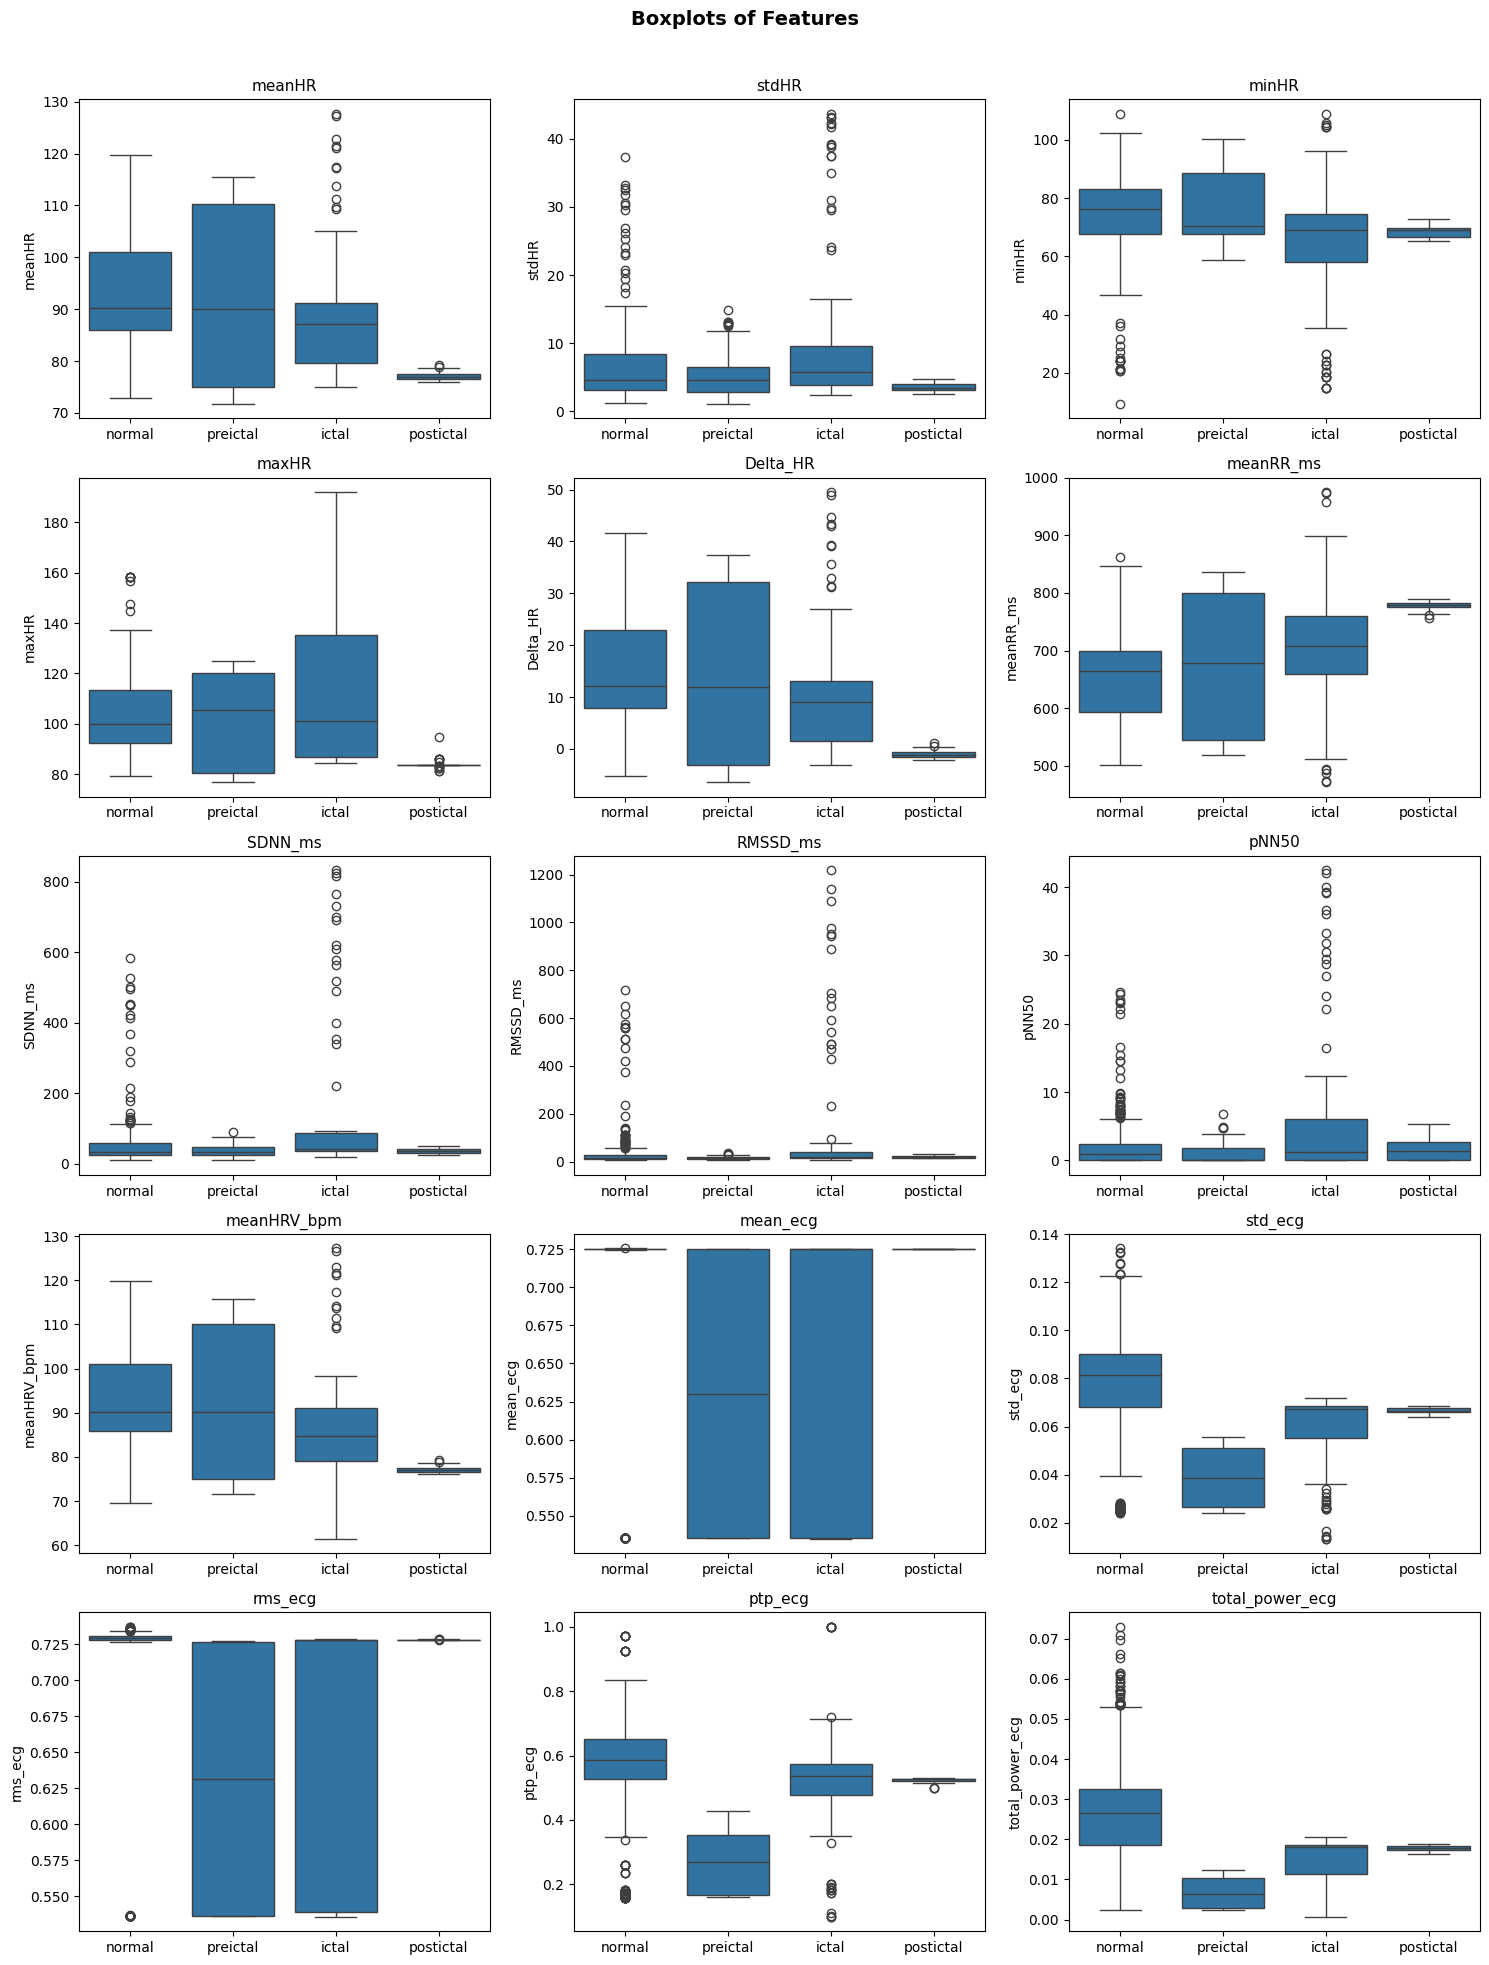

In [28]:
Run_ECG_Function(ecg_files, "ECG125", "box")

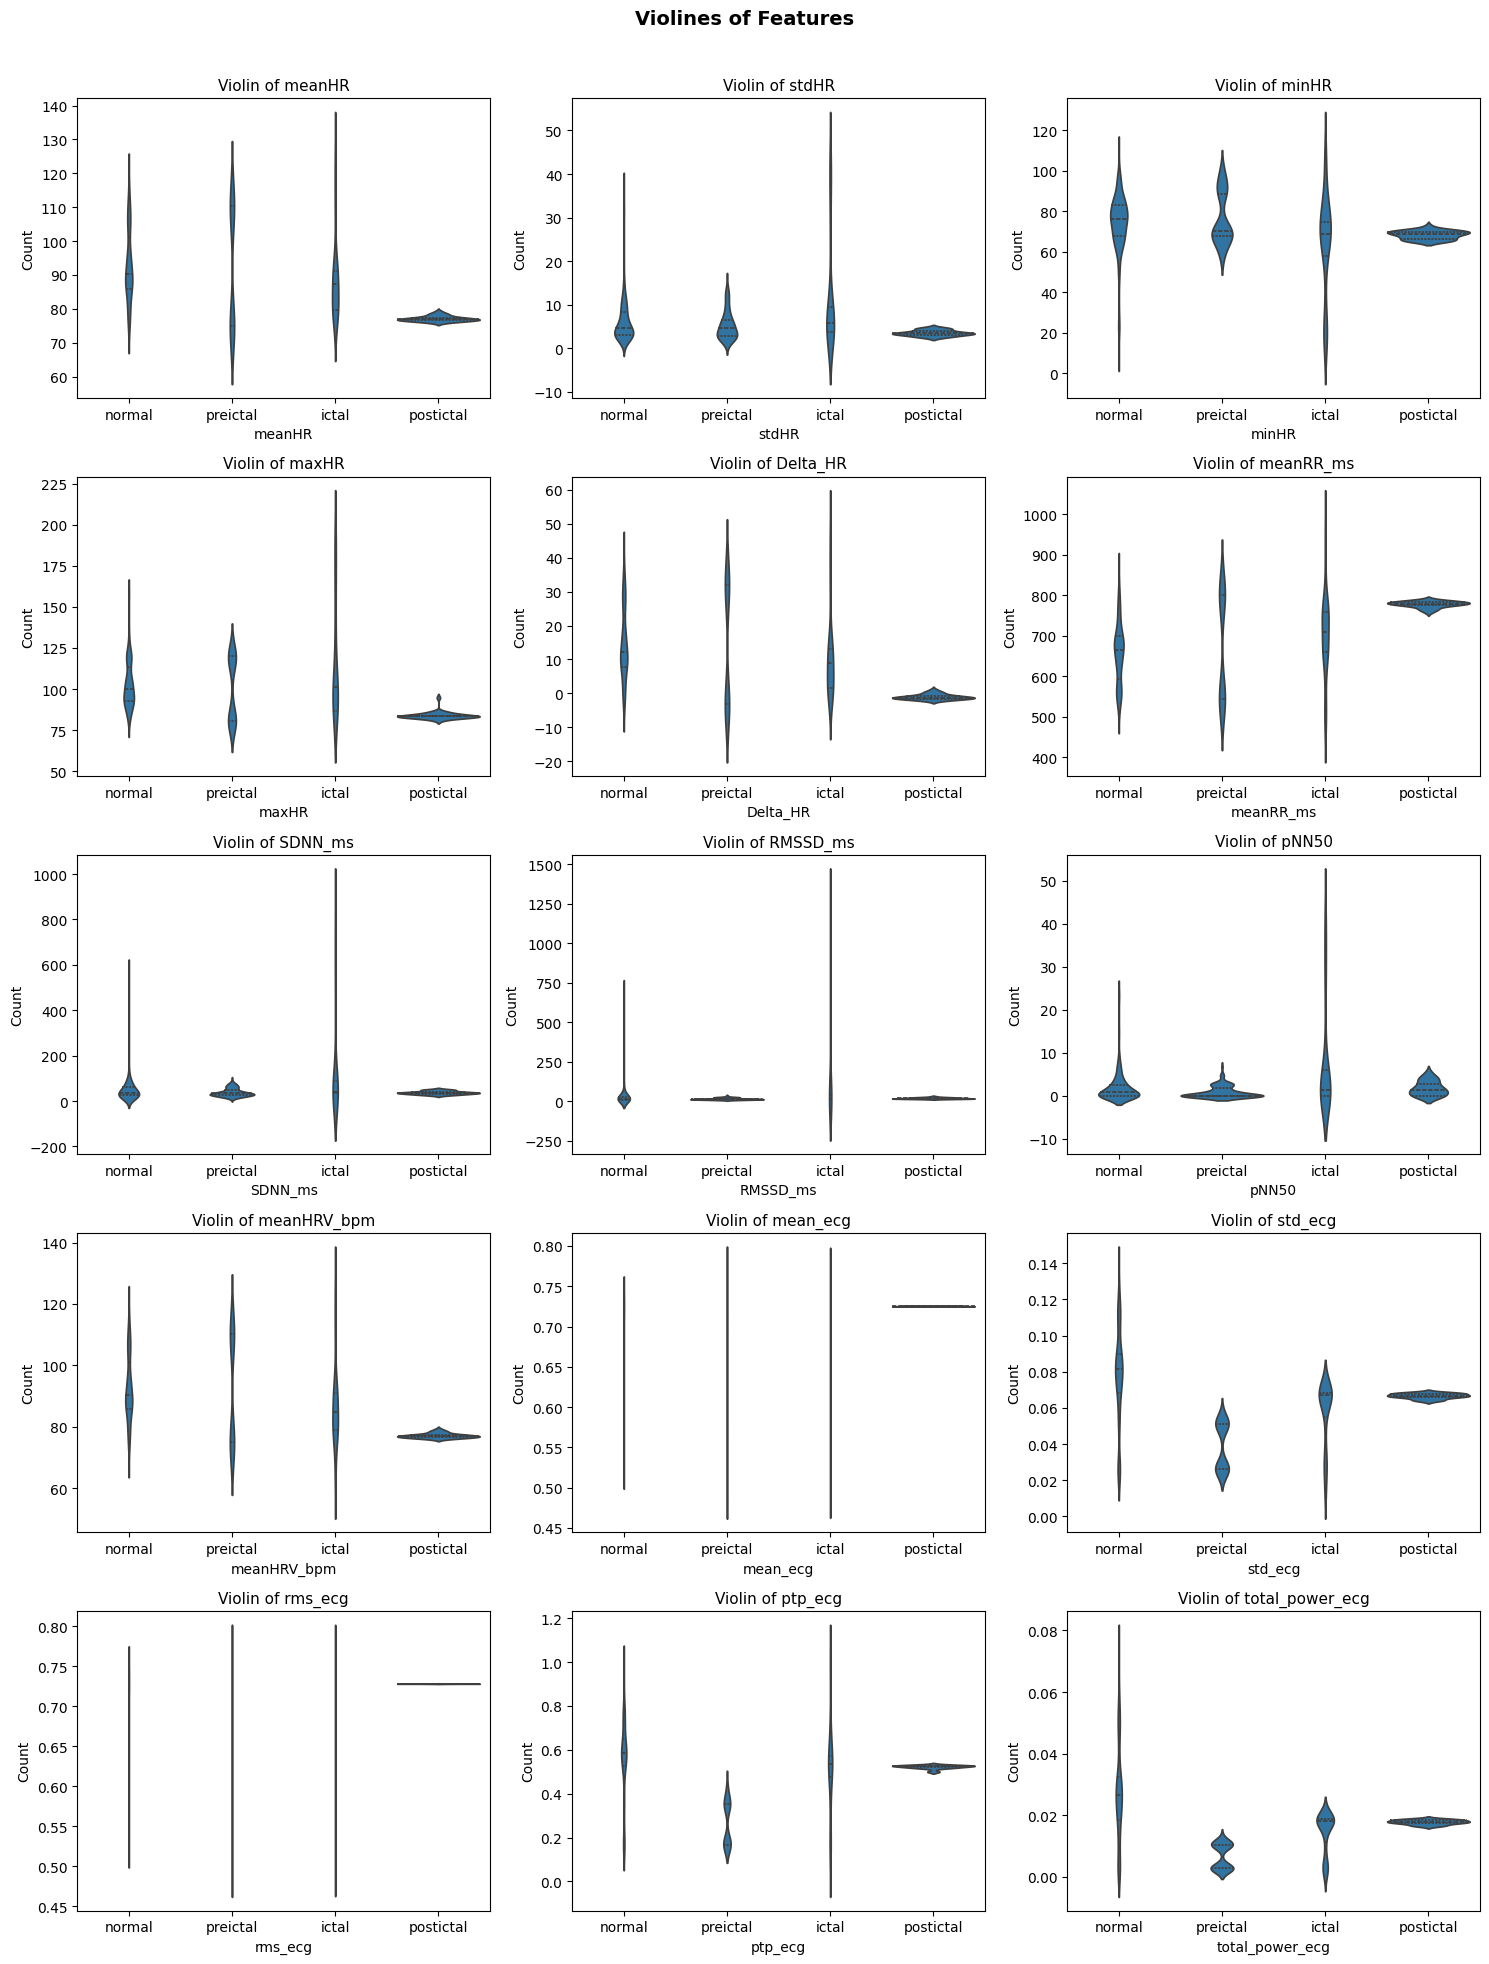

In [29]:
Run_ECG_Function(ecg_files, "ECG125", "violin")

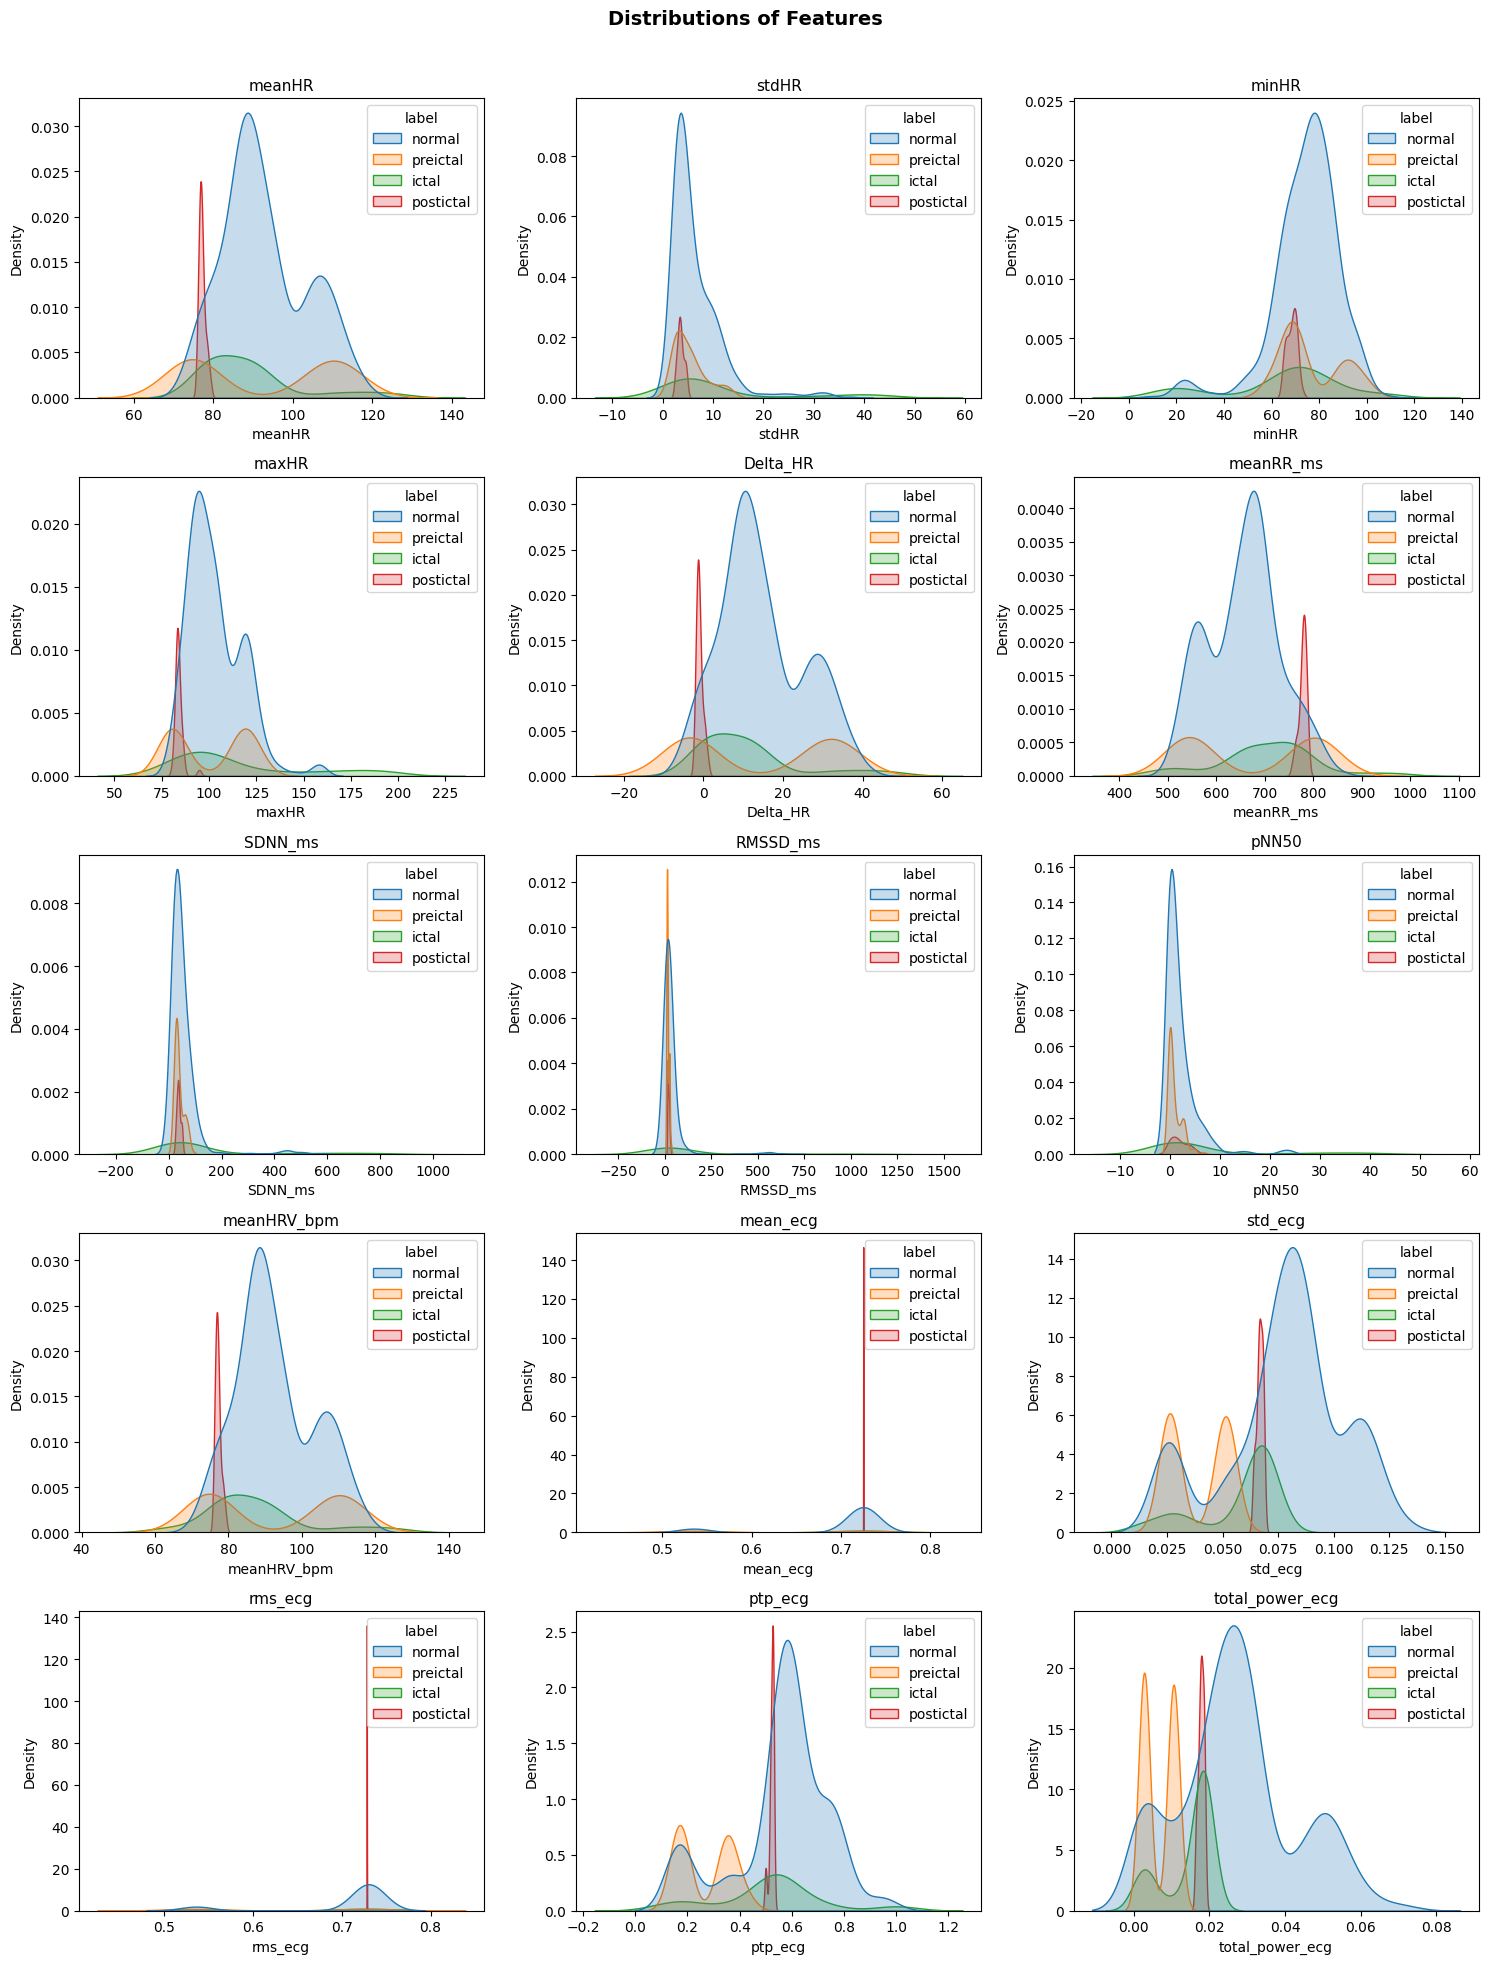

In [30]:
Run_ECG_Function(ecg_files, "ECG125", "dist")


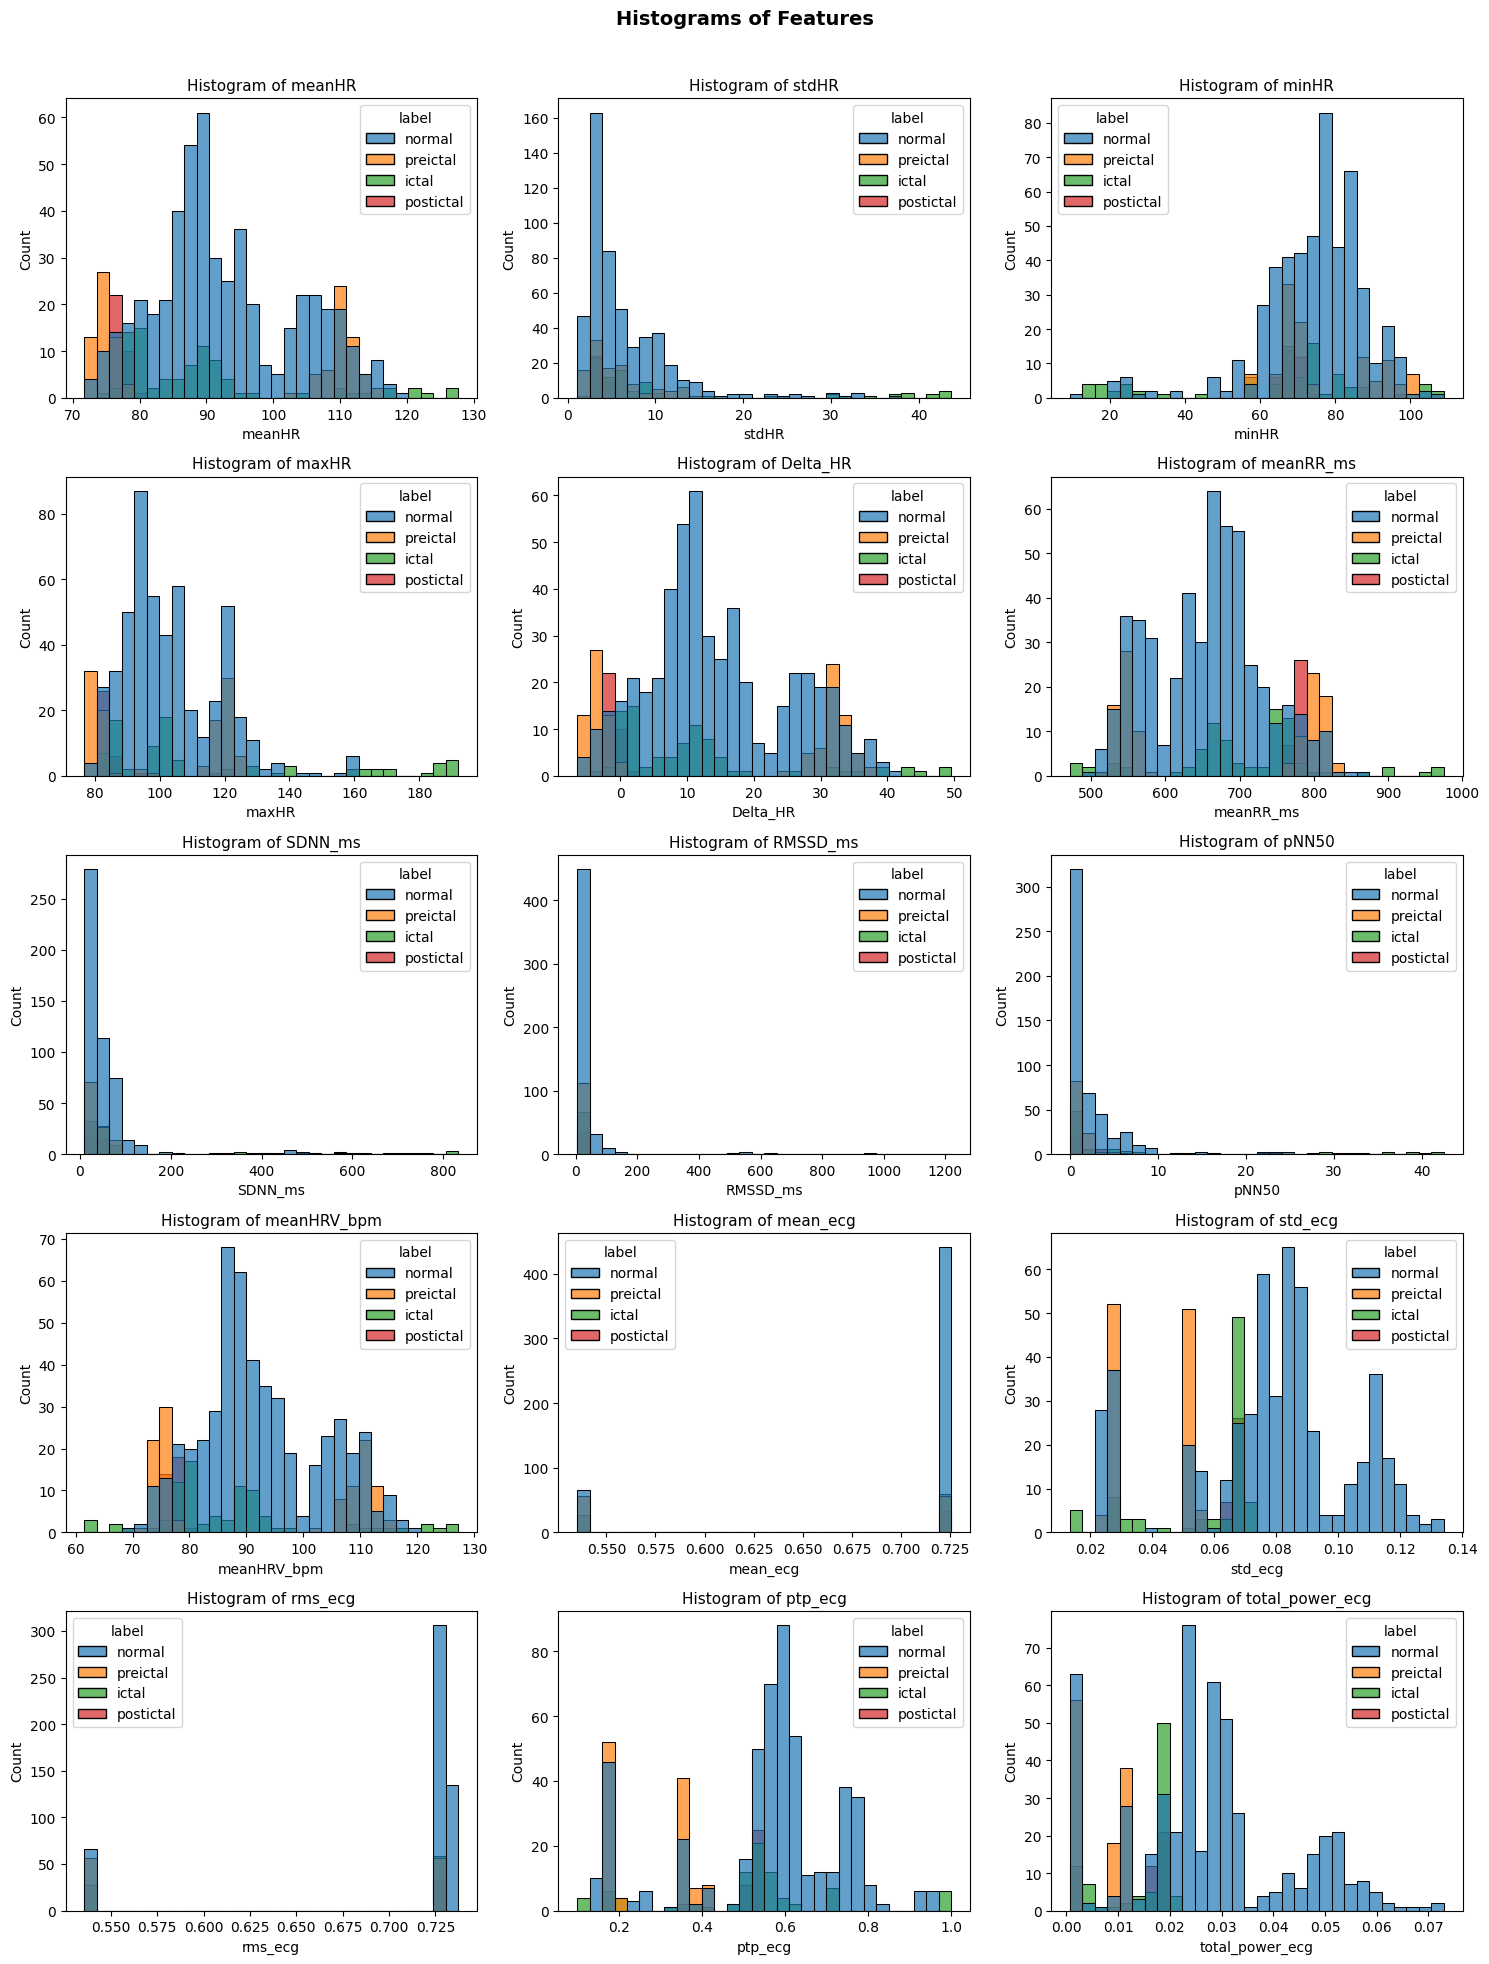

In [31]:
Run_ECG_Function(ecg_files, "ECG125", "hist")


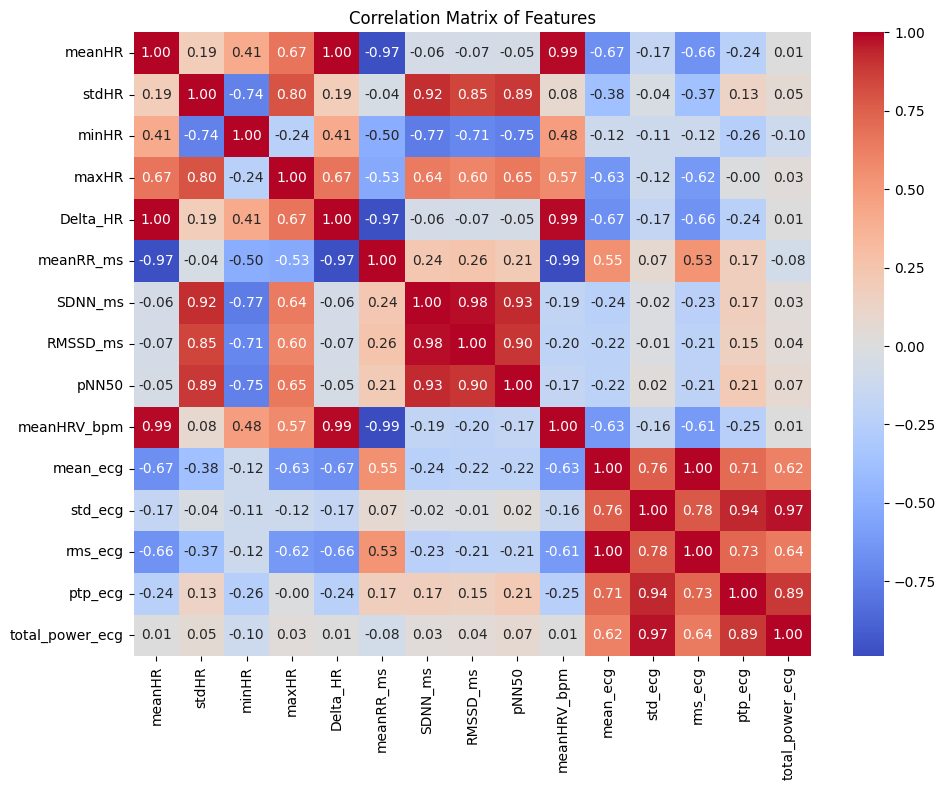

In [32]:
Run_ECG_Function(ecg_files, "ECG125", "corr")


##### Numerical

In [36]:
df125 = ecg_files["ECG125"]
df125 = convert(df125)
Label_counts = df125['status'].value_counts().reset_index()
Label_counts.columns = ['Label', 'Count']
Label_counts


,Label,Count
0,success,738


In [35]:
Analysis_Feature(df125, label_col='label')

Analyzing 17 numeric features: ['meanHR', 'stdHR', 'minHR', 'maxHR', 'Delta_HR', 'meanRR_ms', 'SDNN_ms', 'RMSSD_ms', 'pNN50', 'meanHRV_bpm', 'mean_ecg', 'std_ecg', 'rms_ecg', 'ptp_ecg', 'total_power_ecg', 'bp_0_5_3_ecg', 'n_beats']

==== Feature: meanHR ====


,Label,Min,Max,Mean,Std,Median,25th_percentile,75th_percentile
0,preictal,71.731806,115.581437,92.488113,17.906692,89.989690,74.957495,110.245572
1,normal,72.961465,119.781714,91.766109,10.834365,89.865139,84.640108,97.995131
2,ictal,75.039377,127.664451,89.163630,12.717264,87.196971,79.611246,91.221144


==== Feature: stdHR ====


,Label,Min,Max,Mean,Std,Median,25th_percentile,75th_percentile
0,ictal,2.381083,43.664127,11.785000,12.903464,5.762892,3.853582,9.554042
1,normal,1.282004,37.292328,6.246951,5.111121,4.491731,3.145381,8.094833
2,preictal,1.082616,14.802948,5.354145,3.232931,4.636319,2.825651,6.470786


==== Feature: minHR ====


...

,Label,Min,Max,Mean,Std,Median,25th_percentile,75th_percentile
0,normal,0.002319,0.072971,0.026543,0.015145,0.024599,0.017815,0.031972
1,ictal,0.000712,0.020555,0.014396,0.006600,0.018051,0.011312,0.018665
2,preictal,0.002351,0.012354,0.006692,0.003955,0.006479,0.002793,0.010465


==== Feature: bp_0_5_3_ecg ====


,Label,Min,Max,Mean,Std,Median,25th_percentile,75th_percentile
0,normal,0.000203,0.008637,0.002542,0.001477,0.002392,0.001748,0.003059
1,ictal,0.000088,0.001828,0.001287,0.000582,0.001550,0.001016,0.001748
2,preictal,0.000209,0.001446,0.000742,0.000496,0.000712,0.000253,0.001221


==== Feature: n_beats ====


,Label,Min,Max,Mean,Std,Median,25th_percentile,75th_percentile
0,preictal,71,115,91.901786,17.701713,90.0,74.0,109.00
1,normal,69,119,90.970370,10.787845,89.0,84.0,97.00
2,ictal,61,126,86.500000,13.988861,84.5,79.0,90.75


In [ ]:
Run_ECG_Function(ecg_files, "ECG125", "stats")


#### ECG124

##### Vissualize

In [ ]:
Run_ECG_Function(ecg_files, "ECG124", "box")

In [ ]:
Run_ECG_Function(ecg_files, "ECG124", "violin")

In [ ]:
Run_ECG_Function(ecg_files, "ECG124", "dist")


In [ ]:
Run_ECG_Function(ecg_files, "ECG124", "hist")


In [ ]:
Run_ECG_Function(ecg_files, "ECG124", "corr")


##### Numerical

In [ ]:
df124 = ecg_files["ECG124"]
Label_counts = df124['label'].value_counts().reset_index()
Label_counts.columns = ['Label', 'Count']
Label_counts


In [ ]:
Run_ECG_Function(ecg_files, "ECG124", "analysis")


In [ ]:
Run_ECG_Function(ecg_files, "ECG124", "stats")


#### ECG123

##### Vissualize

In [ ]:
Run_ECG_Function(ecg_files, "ECG123", "box")

In [ ]:
Run_ECG_Function(ecg_files, "ECG123", "violin")

In [ ]:
Run_ECG_Function(ecg_files, "ECG123", "dist")


In [ ]:
Run_ECG_Function(ecg_files, "ECG123", "hist")


In [ ]:
Run_ECG_Function(ecg_files, "ECG125", "corr")


##### Numerical

In [ ]:
df123 = ecg_files["ECG123"]
Label_counts = df123['label'].value_counts().reset_index()
Label_counts.columns = ['Label', 'Count']
Label_counts


In [ ]:
Run_ECG_Function(ecg_files, "ECG123", "analysis")


In [ ]:
Run_ECG_Function(ecg_files, "ECG123", "stats")


#### ECG122

##### Vissualize

In [ ]:
Run_ECG_Function(ecg_files, "ECG122", "box")

In [ ]:
Run_ECG_Function(ecg_files, "ECG122", "violin")

In [ ]:
Run_ECG_Function(ecg_files, "ECG122", "dist")


In [ ]:
Run_ECG_Function(ecg_files, "ECG122", "hist")


In [ ]:
Run_ECG_Function(ecg_files, "ECG122", "corr")


##### Numerical

In [ ]:
df122 = ecg_files["ECG122"]
Label_counts = df122['label'].value_counts().reset_index()
Label_counts.columns = ['Label', 'Count']
Label_counts


In [ ]:
Run_ECG_Function(ecg_files, "ECG122", "analysis")


In [ ]:
Run_ECG_Function(ecg_files, "ECG122", "stats")


#### ECG121

##### Vissualize

In [ ]:
Run_ECG_Function(ecg_files, "ECG121", "box")

In [ ]:
Run_ECG_Function(ecg_files, "ECG121", "violin")

In [ ]:
Run_ECG_Function(ecg_files, "ECG121", "dist")


In [ ]:
Run_ECG_Function(ecg_files, "ECG121", "hist")


In [ ]:
Run_ECG_Function(ecg_files, "ECG121", "corr")


##### Numerical

In [ ]:
df121 = ecg_files["ECG121"]
Label_counts = df121['label'].value_counts().reset_index()
Label_counts.columns = ['Label', 'Count']
Label_counts


In [ ]:
Run_ECG_Function(ecg_files, "ECG121", "analysis")


In [ ]:
Run_ECG_Function(ecg_files, "ECG121", "stats")


#### ECG118

##### Vissualize

In [ ]:
Run_ECG_Function(ecg_files, "ECG118", "box")

In [ ]:
Run_ECG_Function(ecg_files, "ECG118", "violin")

In [ ]:
Run_ECG_Function(ecg_files, "ECG118", "dist")


In [ ]:
Run_ECG_Function(ecg_files, "ECG118", "hist")


In [ ]:
Run_ECG_Function(ecg_files, "ECG118", "corr")


##### Numerical

In [ ]:
df118 = ecg_files["ECG118"]
Label_counts = df118['label'].value_counts().reset_index()
Label_counts.columns = ['Label', 'Count']
Label_counts


In [ ]:
Run_ECG_Function(ecg_files, "ECG118", "analysis")


In [ ]:
Run_ECG_Function(ecg_files, "ECG118", "stats")


#### ECG110

##### Vissualize

In [ ]:
Run_ECG_Function(ecg_files, "ECG110", "box")

In [ ]:
Run_ECG_Function(ecg_files, "ECG110", "violin")

In [ ]:
Run_ECG_Function(ecg_files, "ECG110", "dist")


In [ ]:
Run_ECG_Function(ecg_files, "ECG110", "hist")


In [ ]:
Run_ECG_Function(ecg_files, "ECG110", "corr")


##### Numerical

In [ ]:
df110 = ecg_files["ECG110"]
Label_counts = df110['label'].value_counts().reset_index()
Label_counts.columns = ['Label', 'Count']
Label_counts


In [ ]:
Run_ECG_Function(ecg_files, "ECG110", "analysis")


In [ ]:
Run_ECG_Function(ecg_files, "ECG110", "stats")


#### ECG100

##### Vissualize

In [ ]:
Run_ECG_Function(ecg_files, "ECG100", "box")

In [ ]:
Run_ECG_Function(ecg_files, "ECG100", "violin")

In [ ]:
Run_ECG_Function(ecg_files, "ECG100", "dist")


In [ ]:
Run_ECG_Function(ecg_files, "ECG100", "hist")


In [ ]:
Run_ECG_Function(ecg_files, "ECG100", "corr")


##### Numerical

In [ ]:
df100 = ecg_files["ECG100"]
Label_counts = df100['label'].value_counts().reset_index()
Label_counts.columns = ['Label', 'Count']
Label_counts


In [ ]:
Run_ECG_Function(ecg_files, "ECG100", "analysis")


In [ ]:
Run_ECG_Function(ecg_files, "ECG100", "stats")


#### ECG96

##### Vissualize

In [ ]:
Run_ECG_Function(ecg_files, "ECG96", "box")

In [ ]:
Run_ECG_Function(ecg_files, "ECG96", "violin")

In [ ]:
Run_ECG_Function(ecg_files, "ECG96", "dist")

In [ ]:
Run_ECG_Function(ecg_files, "ECG96", "hist")

In [ ]:
Run_ECG_Function(ecg_files, "ECG96", "corr")

##### Numerical

In [ ]:
df96 = ecg_files["ECG96"]
Label_counts = df96['label'].value_counts().reset_index()
Label_counts.columns = ['Label', 'Count']
Label_counts

In [ ]:
Run_ECG_Function(ecg_files, "ECG96", "analysis")

In [ ]:
Run_ECG_Function(ecg_files, "ECG96", "stats")

#### ECG95

##### Vissualize

In [ ]:
Run_ECG_Function(ecg_files, "ECG95", "box")

In [ ]:
Run_ECG_Function(ecg_files, "ECG95", "violin")

In [ ]:
Run_ECG_Function(ecg_files, "ECG95", "dist")

In [ ]:
Run_ECG_Function(ecg_files, "ECG95", "hist")

In [ ]:
Run_ECG_Function(ecg_files, "ECG95", "corr")

##### Numerical

In [ ]:
df95 = ecg_files["ECG95"]
Label_counts = df95['label'].value_counts().reset_index()
Label_counts.columns = ['Label', 'Count']
Label_counts

In [ ]:
Run_ECG_Function(ecg_files, "ECG95", "analysis")

In [ ]:
Run_ECG_Function(ecg_files, "ECG95", "stats")

#### ECG94

##### Vissualize

In [ ]:
Run_ECG_Function(ecg_files, "ECG94", "box")

In [ ]:
Run_ECG_Function(ecg_files, "ECG94", "violin")

In [ ]:
Run_ECG_Function(ecg_files, "ECG94", "dist")

In [ ]:
Run_ECG_Function(ecg_files, "ECG94", "hist")

In [ ]:
Run_ECG_Function(ecg_files, "ECG94", "corr")

##### Numerical

In [ ]:
df94 = ecg_files["ECG94"]
Label_counts = df94['label'].value_counts().reset_index()
Label_counts.columns = ['Label', 'Count']
Label_counts

In [ ]:
Run_ECG_Function(ecg_files, "ECG94", "analysis")

In [ ]:
Run_ECG_Function(ecg_files, "ECG94", "stats")

#### ECG93

##### Vissualize

In [ ]:
Run_ECG_Function(ecg_files, "ECG93", "box")

In [ ]:
Run_ECG_Function(ecg_files, "ECG93", "violin")

In [ ]:
Run_ECG_Function(ecg_files, "ECG93", "dist")

In [ ]:
Run_ECG_Function(ecg_files, "ECG93", "hist")

In [ ]:
Run_ECG_Function(ecg_files, "ECG93", "corr")

##### Numerical

In [ ]:
df93 = ecg_files["ECG93"]
Label_counts = df93['label'].value_counts().reset_index()
Label_counts.columns = ['Label', 'Count']
Label_counts

In [ ]:
Run_ECG_Function(ecg_files, "ECG93", "analysis")

In [ ]:
Run_ECG_Function(ecg_files, "ECG93", "stats")

#### ECG91

##### Vissualize

In [ ]:
Run_ECG_Function(ecg_files, "ECG91", "box")

In [ ]:
Run_ECG_Function(ecg_files, "ECG91", "violin")

In [ ]:
Run_ECG_Function(ecg_files, "ECG91", "dist")

In [ ]:
Run_ECG_Function(ecg_files, "ECG91", "hist")

In [ ]:
Run_ECG_Function(ecg_files, "ECG91", "corr")

##### Numerical

In [ ]:
df91 = ecg_files["ECG91"]
Label_counts = df91['label'].value_counts().reset_index()
Label_counts.columns = ['Label', 'Count']
Label_counts

In [ ]:
Run_ECG_Function(ecg_files, "ECG91", "analysis")

In [ ]:
Run_ECG_Function(ecg_files, "ECG91", "stats")

#### ECG90

##### Vissualize

In [ ]:
Run_ECG_Function(ecg_files, "ECG90", "box")

In [ ]:
Run_ECG_Function(ecg_files, "ECG90", "violin")

In [ ]:
Run_ECG_Function(ecg_files, "ECG90", "dist")

In [ ]:
Run_ECG_Function(ecg_files, "ECG90", "hist")

In [ ]:
Run_ECG_Function(ecg_files, "ECG90", "corr")

##### Numerical

In [ ]:
df90 = ecg_files["ECG90"]
Label_counts = df90['label'].value_counts().reset_index()
Label_counts.columns = ['Label', 'Count']
Label_counts


In [ ]:
Run_ECG_Function(ecg_files, "ECG90", "analysis")


In [ ]:
Run_ECG_Function(ecg_files, "ECG90", "stats")


#### ECG89

##### Vissualize

In [ ]:
Run_ECG_Function(ecg_files, "ECG89", "box")

In [ ]:
Run_ECG_Function(ecg_files, "ECG89", "violin")

In [ ]:
Run_ECG_Function(ecg_files, "ECG89", "dist")

In [ ]:
Run_ECG_Function(ecg_files, "ECG89", "hist")

In [ ]:
Run_ECG_Function(ecg_files, "ECG89", "corr")

##### Numerical

In [ ]:
df89 = ecg_files["ECG89"]
Label_counts = df89['label'].value_counts().reset_index()
Label_counts.columns = ['Label', 'Count']
Label_counts

In [ ]:
Run_ECG_Function(ecg_files, "ECG89", "analysis")

In [ ]:
Run_ECG_Function(ecg_files, "ECG89", "stats")

#### ECG88

##### Vissualize

In [ ]:
Run_ECG_Function(ecg_files, "ECG88", "box")

In [ ]:
Run_ECG_Function(ecg_files, "ECG88", "violin")

In [ ]:
Run_ECG_Function(ecg_files, "ECG88", "dist")

In [ ]:
Run_ECG_Function(ecg_files, "ECG88", "hist")

In [ ]:
Run_ECG_Function(ecg_files, "ECG88", "corr")

##### Numerical

In [ ]:
df88 = ecg_files["ECG88"]
Label_counts = df88['label'].value_counts().reset_index()
Label_counts.columns = ['Label', 'Count']
Label_counts

In [ ]:
Run_ECG_Function(ecg_files, "ECG88", "analysis")

In [ ]:
Run_ECG_Function(ecg_files, "ECG88", "stats")

#### ECG86

##### Vissualize

In [ ]:
Run_ECG_Function(ecg_files, "ECG86", "box")

In [ ]:
Run_ECG_Function(ecg_files, "ECG86", "violin")

In [ ]:
Run_ECG_Function(ecg_files, "ECG86", "dist")

In [ ]:
Run_ECG_Function(ecg_files, "ECG86", "hist")

In [ ]:
Run_ECG_Function(ecg_files, "ECG86", "corr")

##### Numerical

In [ ]:
df86 = ecg_files["ECG86"]
Label_counts = df86['label'].value_counts().reset_index()
Label_counts.columns = ['Label', 'Count']
Label_counts

In [ ]:
Run_ECG_Function(ecg_files, "ECG86", "analysis")

In [ ]:
Run_ECG_Function(ecg_files, "ECG86", "stats")

#### ECG85

##### Vissualize

In [ ]:
Run_ECG_Function(ecg_files, "ECG85", "box")

In [ ]:
Run_ECG_Function(ecg_files, "ECG85", "violin")

In [ ]:
Run_ECG_Function(ecg_files, "ECG85", "dist")

In [ ]:
Run_ECG_Function(ecg_files, "ECG85", "hist")

In [ ]:
Run_ECG_Function(ecg_files, "ECG85", "corr")

##### Numerical

In [ ]:
df85 = ecg_files["ECG85"]
Label_counts = df85['label'].value_counts().reset_index()
Label_counts.columns = ['Label', 'Count']
Label_counts

In [ ]:
Run_ECG_Function(ecg_files, "ECG85", "analysis")

In [ ]:
Run_ECG_Function(ecg_files, "ECG85", "stats")

#### ECG84

##### Vissualize

In [ ]:
Run_ECG_Function(ecg_files, "ECG84", "box")

In [ ]:
Run_ECG_Function(ecg_files, "ECG84", "violin")

In [ ]:
Run_ECG_Function(ecg_files, "ECG84", "dist")

In [ ]:
Run_ECG_Function(ecg_files, "ECG84", "hist")

In [ ]:
Run_ECG_Function(ecg_files, "ECG84", "corr")

##### Numerical

In [ ]:
df84 = ecg_files["ECG84"]
Label_counts = df84['label'].value_counts().reset_index()
Label_counts.columns = ['Label', 'Count']
Label_counts

In [ ]:
Run_ECG_Function(ecg_files, "ECG84", "analysis")

In [ ]:
Run_ECG_Function(ecg_files, "ECG84", "stats")

#### ECG83

##### Vissualize

In [ ]:
Run_ECG_Function(ecg_files, "ECG83", "box")

In [ ]:
Run_ECG_Function(ecg_files, "ECG83", "violin")

In [ ]:
Run_ECG_Function(ecg_files, "ECG83", "dist")

In [ ]:
Run_ECG_Function(ecg_files, "ECG83", "hist")

In [ ]:
Run_ECG_Function(ecg_files, "ECG83", "corr")

##### Numerical

In [ ]:
df83 = ecg_files["ECG83"]
Label_counts = df83['label'].value_counts().reset_index()
Label_counts.columns = ['Label', 'Count']
Label_counts

In [ ]:
Run_ECG_Function(ecg_files, "ECG83", "analysis")

In [ ]:
Run_ECG_Function(ecg_files, "ECG83", "stats")

#### ECG81

##### Vissualize

In [ ]:
Run_ECG_Function(ecg_files, "ECG81", "box")

In [ ]:
Run_ECG_Function(ecg_files, "ECG81", "violin")

In [ ]:
Run_ECG_Function(ecg_files, "ECG81", "dist")

In [ ]:
Run_ECG_Function(ecg_files, "ECG81", "hist")

In [ ]:
Run_ECG_Function(ecg_files, "ECG81", "corr")

##### Numerical

In [ ]:
df81 = ecg_files["ECG81"]
Label_counts = df81['label'].value_counts().reset_index()
Label_counts.columns = ['Label', 'Count']
Label_counts

In [ ]:
Run_ECG_Function(ecg_files, "ECG81", "analysis")

In [ ]:
Run_ECG_Function(ecg_files, "ECG81", "stats")

#### ECG76

##### Vissualize

In [ ]:
Run_ECG_Function(ecg_files, "ECG76", "box")

In [ ]:
Run_ECG_Function(ecg_files, "ECG76", "violin")

In [ ]:
Run_ECG_Function(ecg_files, "ECG76", "dist")

In [ ]:
Run_ECG_Function(ecg_files, "ECG76", "hist")

In [ ]:
Run_ECG_Function(ecg_files, "ECG76", "corr")

##### Numerical

In [ ]:
df76 = ecg_files["ECG76"]
Label_counts = df76['label'].value_counts().reset_index()
Label_counts.columns = ['Label', 'Count']
Label_counts

In [ ]:
Run_ECG_Function(ecg_files, "ECG76", "analysis")

In [ ]:
Run_ECG_Function(ecg_files, "ECG76", "stats")

#### ECG75

##### Vissualize

In [ ]:
Run_ECG_Function(ecg_files, "ECG75", "box")

In [ ]:
Run_ECG_Function(ecg_files, "ECG75", "violin")

In [ ]:
Run_ECG_Function(ecg_files, "ECG75", "dist")

In [ ]:
Run_ECG_Function(ecg_files, "ECG75", "hist")

In [ ]:
Run_ECG_Function(ecg_files, "ECG75", "corr")

##### Numerical

In [ ]:
df75 = ecg_files["ECG75"]
Label_counts = df75['label'].value_counts().reset_index()
Label_counts.columns = ['Label', 'Count']
Label_counts

In [ ]:
Run_ECG_Function(ecg_files, "ECG75", "analysis")

In [ ]:
Run_ECG_Function(ecg_files, "ECG75", "stats")